In [ ]:
import matplotlib.pyplot as  plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/synthetic_mobile_sales_2025.csv")
data

,Sale_ID,Brand,Model,Country,Storage,Color,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,...,SUMIF,Unnamed: 16,Unnamed: 17,SUMIFS,Unnamed: 19,COUNTIF,Unnamed: 21,COUNTIFS,Unnamed: 23,IFS
0,1,Realme,Realme Model 2,UK,512GB,Gold,656,20,13120,3.7,...,82.0,NaN,NaN,7.0,NaN,49.0,NaN,13.0,NaN,AVERAGE
1,2,Vivo,Vivo Model 20,Australia,512GB,Blue,1013,9,9117,3.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GOOD PROFFIT
2,3,Motorola,Motorola Model 12,Germany,512GB,White,1471,7,10297,3.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GOOD PROFFIT
3,4,Vivo,Vivo Model 13,USA,512GB,Gold,1220,19,23180,3.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GOOD PROFFIT
4,5,Vivo,Vivo Model 15,UAE,128GB,Silver,375,8,3000,4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,OnePlus,OnePlus Model 5,UK,128GB,Blue,371,10,3710,3.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,497,Xiaomi,Xiaomi Model 4,Canada,128GB,Gold,414,8,3312,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
497,498,Vivo,Vivo Model 9,Pakistan,256GB,Blue,314,17,5338,4.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
498,499,Samsung,Samsung Model 19,France,128GB,Gold,342,1,342,4.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sale_ID          500 non-null    int64  
 1   Brand            500 non-null    object 
 2   Model            499 non-null    object 
 3   Country          500 non-null    object 
 4   Storage          500 non-null    object 
 5   Color            500 non-null    object 
 6   Price_USD        500 non-null    int64  
 7   Units_Sold       500 non-null    int64  
 8   Revenue_USD      500 non-null    int64  
 9   Customer_Rating  500 non-null    float64
 10  Payment_Method   500 non-null    object 
 11  Sale_Month       500 non-null    int64  
 12  Sale_Year        500 non-null    int64  
 13  Unnamed: 13      0 non-null      float64
 14  Unnamed: 14      1 non-null      object 
 15  SUMIF            1 non-null      float64
 16  Unnamed: 16      0 non-null      float64
 17  Unnamed: 17     

In [ ]:
data.columns

Index(['Sale_ID', 'Brand', 'Model', 'Country', 'Storage', 'Color', 'Price_USD',
       'Units_Sold', 'Revenue_USD', 'Customer_Rating', 'Payment_Method',
       'Sale_Month', 'Sale_Year'],
      dtype='object')

In [ ]:
data.shape

(500, 13)

In [ ]:
# to check the null values
data.isnull().sum()

#there is no null values in the data set

,0
Sale_ID,0
Brand,0
Model,0
Country,0
Storage,0
Color,0
Price_USD,0
Units_Sold,0
Revenue_USD,0
Customer_Rating,0


In [ ]:
#check the duplicate values in sales ID
data.duplicated("Sale_ID").sum()

#There is no duplicate values in sales ID

np.int64(0)

In [ ]:
# average mobile price
avg_price=data["Price_USD"].mean()
print(avg_price)

889.884


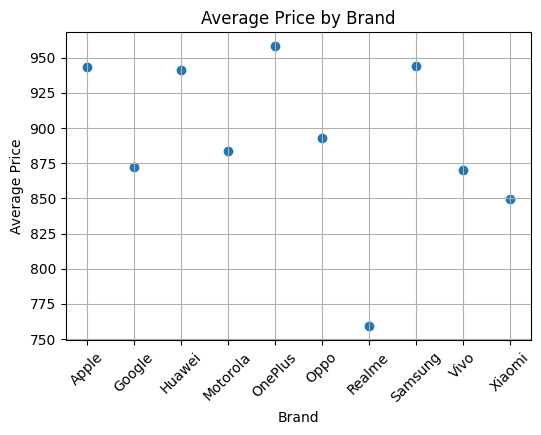

In [ ]:
#plt average mobile price by brand
avg_price = data.groupby("Brand")["Price_USD"].mean()
plt.figure(figsize=(6,4))
plt.scatter(avg_price.index, avg_price.values)
plt.grid(True)
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.title("Average Price by Brand")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# brand performence analysis
# most sold brands
brand_sales = data.groupby("Brand")["Units_Sold"].sum().sort_values(ascending=False)

print(brand_sales)

Brand
Vivo        564
Oppo        552
Motorola    550
Google      534
Xiaomi      526
Huawei      526
Samsung     515
Apple       512
Realme      510
OnePlus     440
Name: Units_Sold, dtype: int64


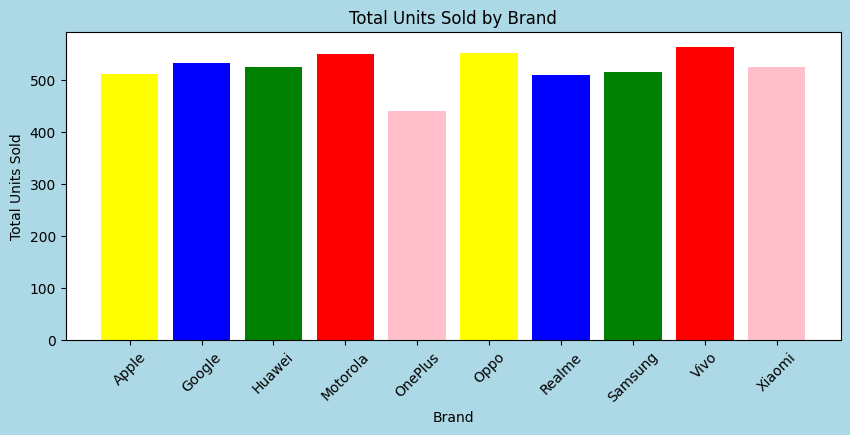

In [ ]:
#comparing units sold of brands with bar chart

brand_sales = data.groupby("Brand")["Units_Sold"].sum()
colors=["yellow","blue","green","red","pink"]
plt.figure(figsize=(10,4),facecolor="lightblue")
plt.bar(brand_sales.index, brand_sales.values,color=colors)
plt.xticks(rotation=45)
plt.xlabel("Brand")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Brand")
plt.show()

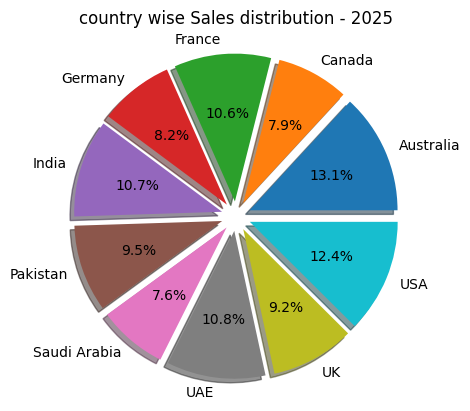

In [ ]:
# country wise sales analysis
brand_sales = data.groupby("Country")["Units_Sold"].sum()
plt.figure()
plt.pie(brand_sales.values, labels=brand_sales.index,shadow=True,autopct="%1.1f%%",explode=[0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1])
plt.title("country wise Sales distribution - 2025")
plt.show()

In [ ]:
# revenue analysis
# total revenue
total_revenue = data["Revenue_USD"].sum()
print(total_revenue)

#average revenue
avg_revenue = data["Revenue_USD"].mean()
print(avg_revenue)

# maximum revenue
max_revenue = data["Revenue_USD"].max()
print(max_revenue)

4639641
9279.282
29660


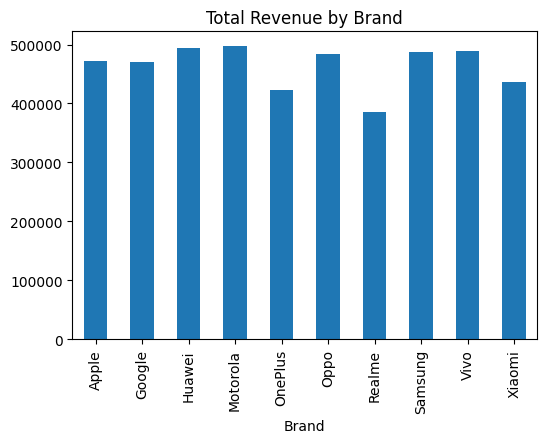

In [ ]:
# total revenue by brand

revenue_brand = data.groupby("Brand")["Revenue_USD"].sum()
plt.figure(figsize=(6,4))

revenue_brand.plot(kind="bar", title="Total Revenue by Brand")
plt.show()

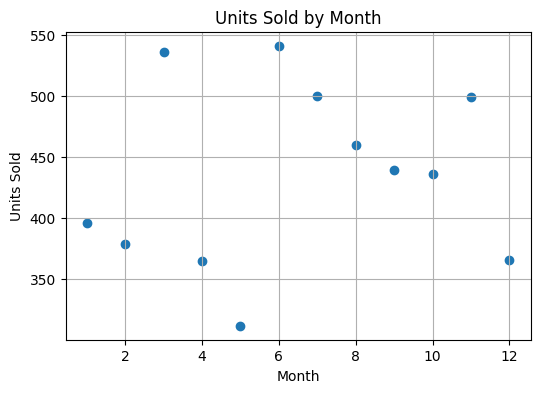

In [ ]:
# units sold for each months
month_sales=data.groupby("Sale_Month")["Units_Sold"].sum()
plt.figure(figsize=(6,4))
plt.scatter(month_sales.index,month_sales.values)
plt.grid(True)
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.title("Units Sold by Month")
plt.show()

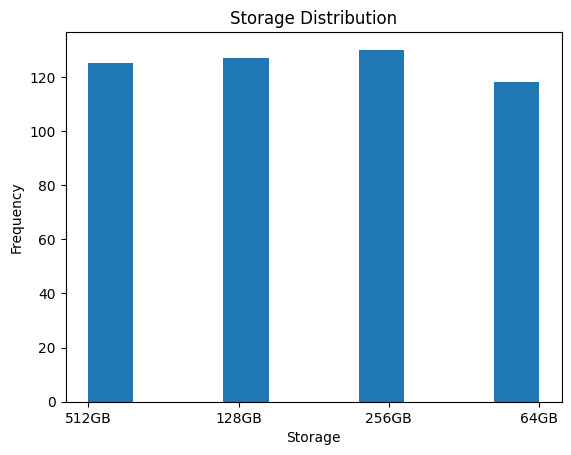

In [ ]:
plt.hist(data["Storage"])
plt.xlabel("Storage")
plt.ylabel("Frequency")
plt.title("Storage Distribution")
plt.show()

In [ ]:
# payment method analys

payment=data["Payment_Method"].value_counts()
payment

,count
Payment_Method,
Cash,107
Credit Card,103
Debit Card,101
Installments,95
Online Payment,94


In [ ]:
# customer ratings for each brands

rating=data.groupby("Brand")["Customer_Rating"].mean().sort_values(ascending=False)
rating

,Customer_Rating
Brand,
Huawei,4.106000
Xiaomi,4.100000
Samsung,4.047059
Vivo,4.043103
Realme,4.034694
Oppo,4.030612
Google,4.015385
OnePlus,3.975000
Motorola,3.967273


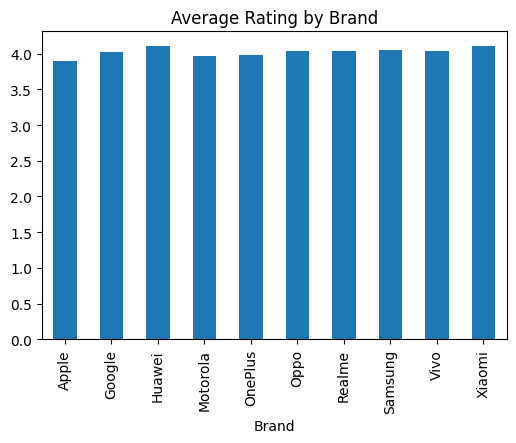

In [ ]:
# average customer ratings by brand
rating_brand = data.groupby("Brand")["Customer_Rating"].mean()
plt.figure(figsize=(6,4))

rating_brand.plot(kind="bar", title="Average Rating by Brand")
plt.show()

In [ ]:
# highest rating of top 5 brands

rating=data.groupby("Brand")["Customer_Rating"].max()
rating.head()

,Customer_Rating
Brand,
Apple,5.0
Google,5.0
Huawei,5.0
Motorola,5.0
OnePlus,5.0


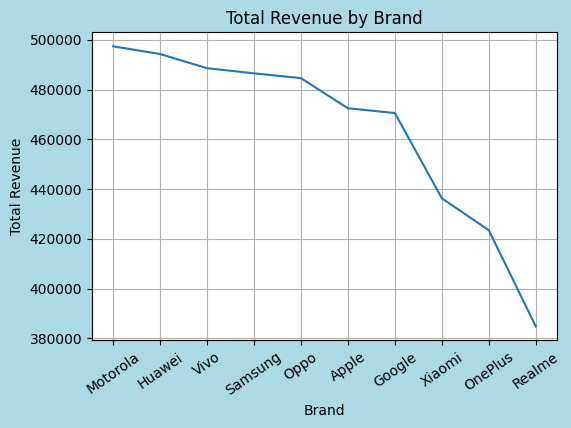

In [ ]:
# total revenue of brands

revenue=data.groupby("Brand")["Revenue_USD"].sum().sort_values(ascending=False)
plt.figure(figsize=(6,4),facecolor="lightblue")
plt.plot(revenue.index,revenue.values)
plt.grid(True)
plt.xlabel("Brand")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Brand")
plt.xticks(rotation=35)
plt.show()


In [ ]:
# total sales for each payment method
payment_method_revenue = data.groupby('Payment_Method')['Revenue_USD'].sum().sort_values(ascending=False)
print(payment_method_revenue)


Payment_Method
Cash              995141
Credit Card       969384
Debit Card        929376
Online Payment    876926
Installments      868814
Name: Revenue_USD, dtype: int64


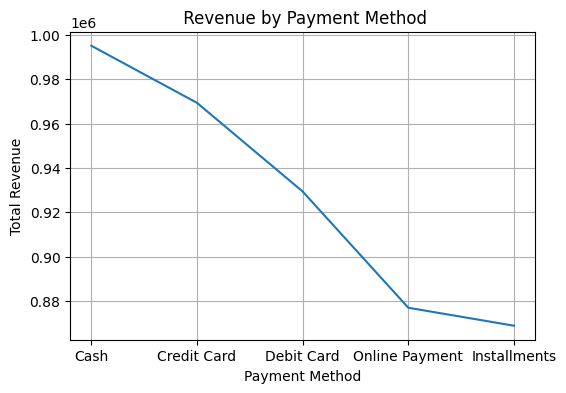

In [ ]:
payment_method_revenue = data.groupby('Payment_Method')['Revenue_USD'].sum().sort_values(ascending=False)
plt.figure(figsize=(6,4))
plt.plot(payment_method_revenue.index,payment_method_revenue.values)
plt.grid(True)
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.title(" Revenue by Payment Method")
plt.show()

In [ ]:
data.groupby(["Country","Brand"])["Units_Sold"].sum().unstack()

Brand,Apple,Google,Huawei,Motorola,OnePlus,Oppo,Realme,Samsung,Vivo,Xiaomi
Country,,,,,,,,,,
Australia,102,51,47,31,47,74,101,92,58,84
Canada,48,18,62,66,21,15,46,54,24,60
France,63,44,22,51,44,46,68,51,118,47
Germany,39,34,78,57,12,40,42,22,33,70
India,40,78,84,69,17,41,65,84,43,38
Pakistan,53,29,45,29,124,25,12,55,103,23
Saudi Arabia,33,30,27,37,22,84,36,44,58,25
UAE,44,72,25,80,61,32,78,51,42,79
UK,53,63,54,70,32,92,41,19,7,48


<Figure size 600x400 with 0 Axes>

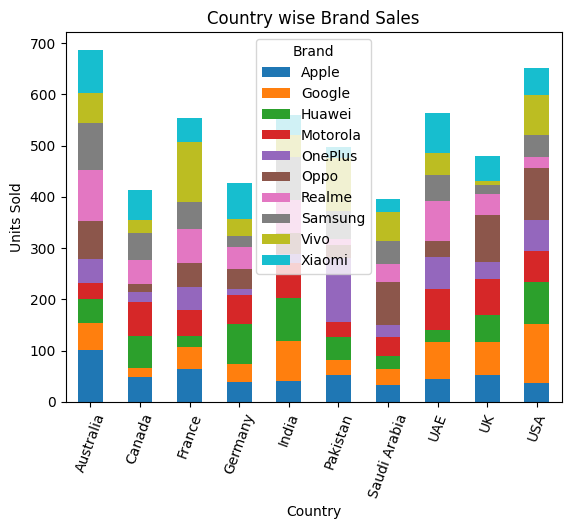

In [ ]:
# country wise brand sales
group_data = data.groupby(["Country","Brand"])["Units_Sold"].sum().unstack()
plt.figure(figsize=(6,4))
group_data.plot(kind="bar", stacked=True)
plt.title("Country wise Brand Sales")
plt.xlabel("Country")
plt.ylabel("Units Sold")
plt.legend(title="Brand")
plt.xticks(rotation=70)

plt.show()

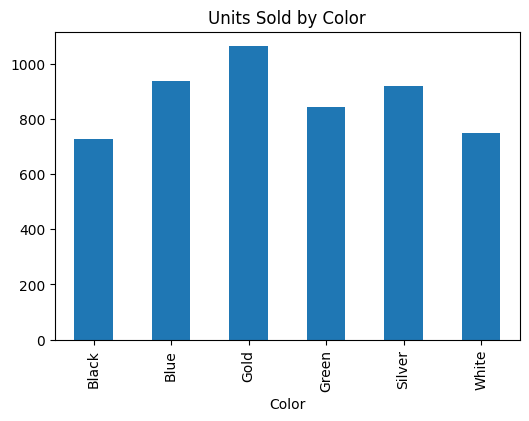

In [ ]:
# unit sold by color
color_units = data.groupby("Color")["Units_Sold"].sum()
plt.figure(figsize=(6,4))

color_units.plot(kind="bar", title="Units Sold by Color")
plt.show()

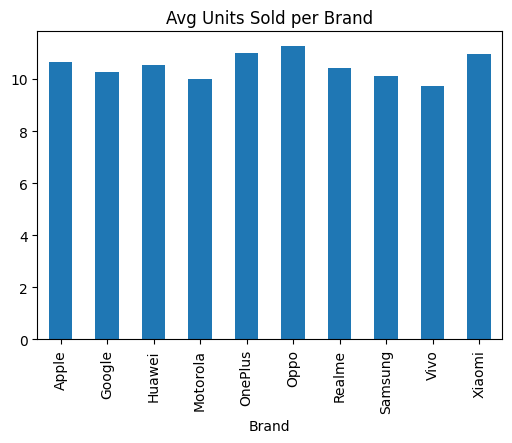

In [ ]:
# average units sold per brand
avg_units = data.groupby("Brand")["Units_Sold"].mean()
plt.figure(figsize=(6,4))

avg_units.plot(kind="bar", title="Avg Units Sold per Brand")
plt.show()

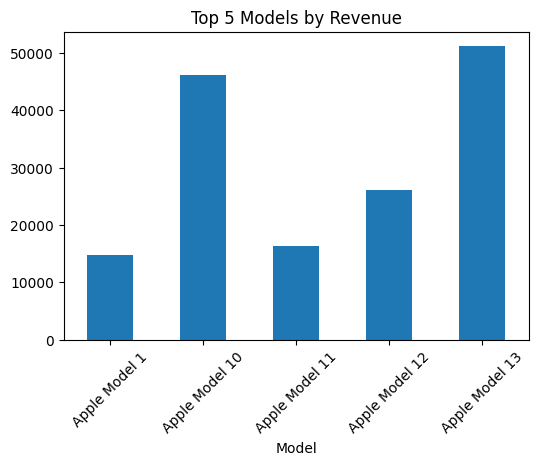

In [ ]:
# top 5 models by revenue
top_models = data.groupby("Model")["Revenue_USD"].sum().head(5)
plt.figure(figsize=(6,4))

top_models.plot(kind="bar", title="Top 5 Models by Revenue")
plt.xticks(rotation=45)
plt.show()